## Laufzeiten der Sortieralgorithmen

Sortieralgorithmen mit quadratischer Laufzeit

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import random
import time 

In [3]:
def selection_sort(a):
    for i in range(len(a)-1):
        best = i
        best_val = a[i]
        for j in range(i+1,len(a)):
            if a[j] < best_val:
                best = j
                best_val = a[j]
        a[best],a[i] = a[i],a[best]

def bubble_sort(a):
    getauscht = True
    while getauscht:
        getauscht = False
        for i in range(len(a)-1):
            if a[i] > a[i+1]:
                a[i],a[i+1]=a[i+1],a[i]
                getauscht = True

def insertion_sort(a):
    for i in range(1,len(a)):
        x = a[i]
        j = i
        while j > 0 and a[j-1] > x:
            a[j] = a[j-1]
            j = j - 1
        a[j] = x

#### Aufgabe 1:

In der nächsten Zelle wird die durchschnittliche Laufzeit für die Sortierung gemessen. Lasse für jeden der drei Sortieralgorithmen die Zelle für N=1,2,4,8,16,32 laufen und trage die Werte in der übernächsten Zelle ein. Bei großem N muss ggf. die Anzahl der Versuche für die Durchschnittsbildung reduziert werden, damit die Berechnung nicht zu lange dauert.


In [5]:
N = 32                         # Anzahl zu sortierender Elemente in Tausend
anzahl_versuche = 1          # Anzahl Sortiervorgänge für die Durchschnittsbildung
summe = 0
for i in range(anzahl_versuche):
    a = [random.randint(-N*1000,N*1000) for _  in range(N*1000)]    # Liste mit Zufallszahlen
    start = time.perf_counter()
    selection_sort(a)         # <------------- update: Sortieralgorithmus 
    end = time.perf_counter()
    summe = summe + (end-start)
print(f'{summe/anzahl_versuche:.3f}')    # Durchschnittliche Laufzeit in Sekunden


17.495


In [5]:
anzahl = [1, 2, 4, 8, 16, 32]                       # Anzahl zu sortierender Elemente in Tausend
selection = [0.016, 0.063, 0.254, 0.997, 4.103, 17.257]
bubble = [0.072, 0.303, 1.250, 5.131, 20.650, 87.676]
insertion=[0.024, 0.097, 0.397, 1.590, 6.470, 26.092 ]

In [8]:
def quadratic_model(x, a, b, c):
    return a * x**2 + b * x + c

params, _ = curve_fit(quadratic_model, anzahl, selection)
a_selection, b_selection, c_selection = params
print(f"selection: f(x) ≈ {a_selection:.8f} * x**2 + {b_selection:.8f} * x + {c_selection}") 
params, _ = curve_fit(quadratic_model, anzahl, bubble)
a_bubble, b_bubble, c_bubble = params
print(f"bubble   : f(x) ≈ {a_bubble:.8f} * x**2 + {b_bubble:.8f} * x + {c_bubble}") 
params, _ = curve_fit(quadratic_model, anzahl, insertion)
a_insertion, b_insertion, c_insertion = params
print(f"insertion: f(x) ≈ {a_insertion:.8f} * x**2 + {b_insertion:.8f} * x + {c_insertion}") 

selection: f(x) ≈ 0.01764757 * x**2 + -0.02727645 * x + 0.053247916666666506
bubble   : f(x) ≈ 0.09012816 * x**2 + -0.15501151 * x + 0.30379791666673484
insertion: f(x) ≈ 0.02570712 * x**2 + -0.00753910 * x + 0.009122916666844394


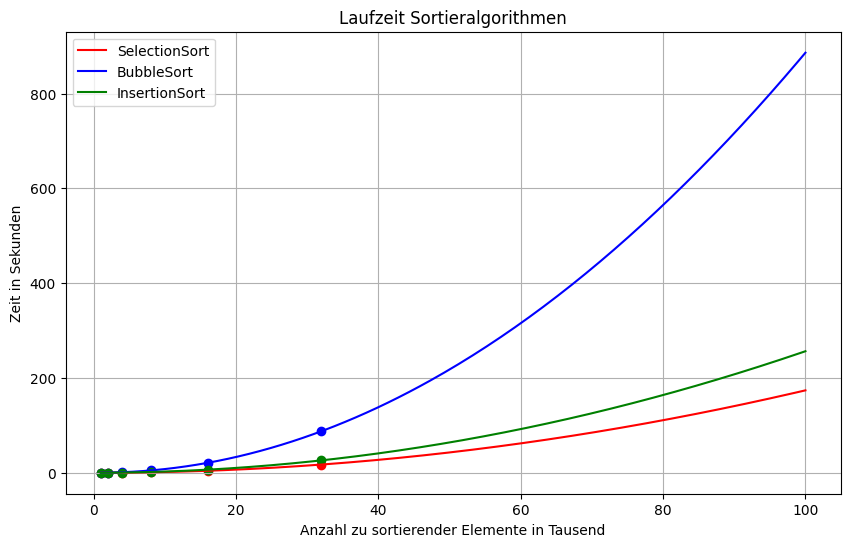

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(anzahl, selection, color='red')
plt.scatter(anzahl, bubble, color='blue')
plt.scatter(anzahl, insertion, color='green')
xs = np.linspace(1,100,200)
plt.plot(xs, quadratic_model(xs, a_selection, b_selection, c_selection), label="SelectionSort", color='red')
plt.plot(xs, quadratic_model(xs, a_bubble, b_bubble, c_bubble), label="BubbleSort", color='blue')
plt.plot(xs, quadratic_model(xs, a_insertion, b_insertion, c_insertion), label="InsertionSort", color='green')
plt.xlabel("Anzahl zu sortierender Elemente in Tausend")
plt.ylabel("Zeit in Sekunden")
plt.title("Laufzeit Sortieralgorithmen")
plt.legend()
plt.grid(True)
plt.show()


#### Aufgabe 2: 

a. Lies aus dem Funktionsgraphen die Zeit ab, die die Sortieralgorithmen für die Eingabegröße 50000 benötigen. Überprüfe die Zahlen durch eine entsprechende Sortierung.

b. Kannst du die Zeit aus Versuch a. auch bestimmen, ohne den Wert aus dem Funktionsgraphen zu bestimmen? 

----

### Sortieralgorithmen mit Laufzeit O(n*log(n))

In [5]:
def merge(a, b):
    i = j = 0
    c=[]
    while i < len(a) and j < len(b):
        if a[i] < b[j]:
            c.append(a[i])
            i+=1
        else:
            c.append(b[j])
            j+=1
    if i == len(a):
        c.extend(b[j:])
    else:
        c.extend(a[i:])
    return c

def merge_sort(a):
    if len(a) <= 1: return a
    halb = len(a)//2
    b = a[:halb]
    c = a[halb:]
    return merge(merge_sort(b),merge_sort(c))

def quick_sort(a, unten = 0, oben = None):
    if oben == None: oben = len(a)-1
    i , j = unten, oben
    mitte = (unten + oben) // 2
    pivot = a[mitte]
    while i <= j:
        while a[i] < pivot: i+=1
        while a[j] > pivot: j-=1
        if i <= j:
            a[i], a[j] = a[j], a[i]
            i+=1
            j-=1
    if unten < j: quick_sort(a,unten,j)
    if i < oben: quick_sort(a,i,oben)

def sift(a, start , end):
    i = start
    x = a[start]
    j = 2 * i + 1
    if j < end and a[j+1] < a[j]:
        j+=1
    while j <= end and a[j] < x:
        a[i] = a[j]
        i = j
        j = j * 2 + 1
        if j < end and a[j+1] < a[j]:
            j+=1
    a[i] = x

def heap_sort(a):
    n = len(a)
    for k in range ((n-2)//2,-1,-1):
        sift(a,k,n-1)
    for k in range(n-1,0,-1):
        a[0],a[k]=a[k],a[0]
        sift(a,0,k-1)

#### Aufgabe 3:

Wie Aufgabe 1, nur für die schnellen Sortieralgorithmen. 
Der in Python eingebaute Sortieralgorithmus heißt TimSort und wird mit a.sort() aufgerufen.

In [18]:
N = 100                      # Anzahl zu sortierender Elemente in Tausend
anzahl_versuche = 4         # Anzahl Sortiervorgänge für die Durchschnittsbildung
summe = 0
for i in range(anzahl_versuche):
    a = [random.randint(-N*1000,N*1000) for _  in range(N*1000)]    # Liste mit Zufallszahlen
    start = time.perf_counter()
    quick_sort(a)            # <------------- update: Sortieralgorithmus 
    end = time.perf_counter()
    summe = summe + (end-start)
print(f'{summe/anzahl_versuche:.3f}')    # Durchschnittliche Laufzeit in Sekunden

0.153


In [19]:
anzahl = [100,200,400,800,1600,3200]
merge = [0.300, 0.719, 1.422, 3.110, 6.718, 14.387]
quick = [0.153, 0.352, 0.767, 1.661, 3.601, 7.969]
heap=[0.629, 1.165, 2.642, 4.881, 9.244, 18.528]
tim=[0.030, 0.072, 0.193, 0.456, 0.804, 1.610]

In [20]:
def n_log_n_model(x, a, b):
    return a * x * np.log(x) + b

params, _ = curve_fit(n_log_n_model, anzahl, merge)
a_merge, b_merge = params
print(f"merge: f(x) ≈ {a_merge:.8f} * x * log(x) + {b_merge:.8f}") 
params, _ = curve_fit(n_log_n_model, anzahl, quick)
a_quick, b_quick = params
print(f"quick: f(x) ≈ {a_quick:.8f} * x * log(x) + {b_quick:.8f}") 
params, _ = curve_fit(n_log_n_model, anzahl, heap)
a_heap, b_heap = params
print(f"heap : f(x) ≈ {a_heap:.8f} * x * log(x) + {b_heap:.8f}") 
params, _ = curve_fit(n_log_n_model, anzahl, tim)
a_tim, b_tim = params
print(f"tim  : f(x) ≈ {a_tim:.8f} * x * log(x) + {b_tim:.8f}") 

merge: f(x) ≈ 0.00055408 * x * log(x) + 0.11203107
quick: f(x) ≈ 0.00030731 * x * log(x) + 0.01522074
heap : f(x) ≈ 0.00069759 * x * log(x) + 0.72918022
tim  : f(x) ≈ 0.00006167 * x * log(x) + 0.04547645


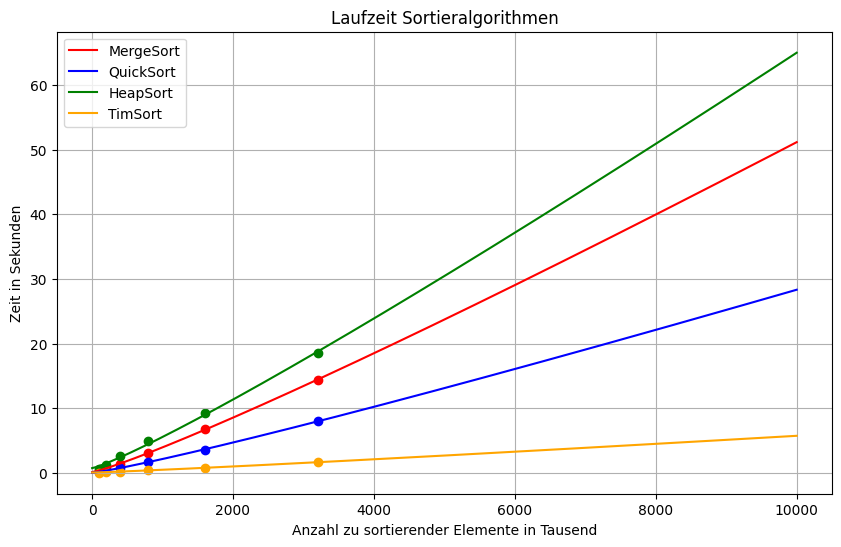

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(anzahl, merge, color='red')
plt.scatter(anzahl, quick, color='blue')
plt.scatter(anzahl, heap, color='green')
plt.scatter(anzahl, tim, color='orange')
xs = np.linspace(1,10000,200)
plt.plot(xs, n_log_n_model(xs, a_merge, b_merge), label="MergeSort", color='red')
plt.plot(xs, n_log_n_model(xs, a_quick, b_quick), label="QuickSort", color='blue')
plt.plot(xs, n_log_n_model(xs, a_heap, b_heap), label="HeapSort", color='green')
plt.plot(xs, n_log_n_model(xs, a_tim, b_tim), label="TimSort", color='orange')
plt.xlabel("Anzahl zu sortierender Elemente in Tausend")
plt.ylabel("Zeit in Sekunden")
plt.title("Laufzeit Sortieralgorithmen")
plt.legend()
plt.grid(True)
plt.show()

 #### Aufgabe 4:

Lies aus den Funktionsgraphen die Zeit ab, die Quicksort für die Sortierung von 10 Millionen Zahlen benötigt und überprüfe das Ergebnis durch einen Versuch.